# Задание 12. Поиск гиперпараметров нейронной сети

Что нужно сделать:
- Взять модель нейронной сети для классификации цифр MNIST из заданий 10 (часть 2) и 11.
- Обернуть ее в еще один цикл — цикл по наборам гиперпараметров, — а внутри каждого набора оценивать
  модель кросс-валидацией. Получается три вложенных цикла: по гиперпараметрам -> по фолдам ->
  по эпохам (и по батчам внутри эпохи).
- Стратегию выбрать одну: **RandomSearch** или GridSearch. Здесь берется **RandomSearch**.
- Варьируемые гиперпараметры: `n_layers`, `n_neurons`, `batch_size` и
  `optimizer` (SGD, Adam, RMSprop, Adagrad).
- Результат — таблица с номером поиска, набором гиперпараметров и усредненными по фолдам
  Accuracy, Precision, Recall, F1-score.

In [1]:
import time
import random
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Часть 1. Данные и модель из заданий 10-11

### Шаг 1. Загружаем MNIST и берем подвыборку

Датасет тот же, что в заданиях 10-11: csv, первый столбец — метка класса, остальные 784 — пиксели
картинки 28x28.

In [2]:
train_df = pd.read_csv("../mnist/mnist_train.csv")
test_df = pd.read_csv("../mnist/mnist_test.csv")

print("обучающая:", train_df.shape, " тестовая:", test_df.shape)
train_df.iloc[:5, :8]

обучающая: (60000, 785)  тестовая: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7
0,5,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0


In [3]:
# пиксели делим на 255, как в задании 10
X_full = train_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y_full = train_df["label"].values

X_test = test_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y_test = test_df["label"].values

print(X_full.shape, X_test.shape)

(60000, 784) (10000, 784)


Условие разрешает не брать все 60000 примеров. Поиск гиперпараметров обучает модель
(число наборов) x (число фолдов) раз, поэтому полный датасет здесь считался бы очень долго.
Берем стратифицированную подвыборку из 5000 примеров и 5 фолдов кросс-валидации
(условие тоже это разрешает — «можно взять меньшее разбиение на фолды: 3 or 5»).

In [4]:
# стратифицированная подвыборка: доли классов такие же, как в полном датасете
X, _, y, _ = train_test_split(X_full, y_full, train_size=5000, stratify=y_full, random_state=42)

print("подвыборка:", X.shape)
print(pd.Series(y).value_counts().sort_index())

подвыборка: (5000, 784)
0    493
1    562
2    496
3    511
4    487
5    452
6    493
7    522
8    488
9    496
Name: count, dtype: int64


Классы в подвыборке остались сбалансированными — по 350-500 примеров на цифру.

### Шаг 2. Модель, которую собираем по гиперпараметрам

В задании 10 сеть была фиксированная: `784 -> 128 -> 10`. Теперь число скрытых слоев и число нейронов
в них — гиперпараметры, поэтому сеть нужно собирать не руками, а функцией: она возвращает
`nn.Sequential` из `n_layers` скрытых слоев по `n_neurons` нейронов с ReLU и выходного слоя на 10 логитов
(softmax считается внутри `nn.CrossEntropyLoss`).

In [5]:
def make_model(n_layers, n_neurons):
    layers = [nn.Linear(784, n_neurons), nn.ReLU()]
    # остальные скрытые слои, если их больше одного
    for _ in range(n_layers - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.ReLU()]
    layers += [nn.Linear(n_neurons, 10)]
    return nn.Sequential(*layers)


print(make_model(2, 64))

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)


Оптимизатор тоже приходит как гиперпараметр — по имени. Держим их в словаре, чтобы в цикле поиска
можно было создать нужный по строке.

In [6]:
optimizers = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "RMSprop": torch.optim.RMSprop,
    "Adagrad": torch.optim.Adagrad,
}

loss_fn = nn.CrossEntropyLoss()
lr = 0.001      # learning rate одинаковый для всех наборов, сравниваем именно оптимизаторы
epochs = 15

### Шаг 3. Обучение и оценка одного набора кросс-валидацией

Внутренняя часть — та же, что в задании 10: цикл по эпохам, внутри перемешиваем индексы через
`torch.randperm` и идем по батчам. Функция обучает сеть на фолде и возвращает четыре метрики на
отложенной части. Precision, Recall и F1 считаем с усреднением `macro` — задача многоклассовая.

In [7]:
X_t = torch.tensor(X)
y_t = torch.tensor(y, dtype=torch.long)


def train_and_score(n_layers, n_neurons, batch_size, optimizer_name, train_idx, test_idx):
    torch.manual_seed(42)                     # чтобы наборы сравнивались с одинаковой инициализацией
    model = make_model(n_layers, n_neurons)
    opt = optimizers[optimizer_name](model.parameters(), lr=lr)

    X_tr, y_tr = X_t[train_idx], y_t[train_idx]

    for ep in range(epochs):
        idx = torch.randperm(len(X_tr))
        for i in range(0, len(X_tr), batch_size):
            b = idx[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_tr[b]), y_tr[b])
            loss.backward()
            opt.step()

    with torch.no_grad():
        pred = model(X_t[test_idx]).argmax(dim=1).numpy()
    true = y[test_idx]

    return [accuracy_score(true, pred),
            precision_score(true, pred, average="macro", zero_division=0),
            recall_score(true, pred, average="macro", zero_division=0),
            f1_score(true, pred, average="macro", zero_division=0)]

Разбиение на фолды — стратифицированный K-fold из задания 11, только с k = 5 вместо 10.

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X, y))

for i, (tr, te) in enumerate(folds, start=1):
    print(f"фолд {i}: train = {len(tr)}, test = {len(te)}")

фолд 1: train = 4000, test = 1000
фолд 2: train = 4000, test = 1000
фолд 3: train = 4000, test = 1000
фолд 4: train = 4000, test = 1000
фолд 5: train = 4000, test = 1000


Проверим, как это работает, на наборе из задания 10 (1 скрытый слой, 128 нейронов, batch 64, Adam),
и заодно измерим время, чтобы посчитать бюджет поиска.

In [9]:
t0 = time.time()

fold_metrics = []
for tr, te in folds:
    fold_metrics.append(train_and_score(1, 128, 64, "Adam", tr, te))

fold_metrics = np.array(fold_metrics)
print("метрики по фолдам (accuracy):", fold_metrics[:, 0].round(4))
print("среднее по фолдам:           ", fold_metrics.mean(axis=0).round(4))
print("время одной кросс-валидации: ", round(time.time() - t0, 1), "с")

метрики по фолдам (accuracy): [0.918 0.91  0.929 0.915 0.92 ]
среднее по фолдам:            [0.9184 0.9191 0.9172 0.9172]
время одной кросс-валидации:  2.1 с


Одна кросс-валидация набора занимает пару секунд, значит на 16 наборов уйдет меньше минуты — такой
бюджет нас устраивает. Полный GridSearch по всей сетке (144 набора) стоил бы в девять раз дороже,
поэтому и берется RandomSearch.

## Часть 2. RandomSearch поверх кросс-валидации

### Шаг 4. Сетка гиперпараметров и случайные наборы

Смысл RandomSearch: не перебирать всю сетку, а взять из нее случайные наборы. Наборов в сетке 144,
берем 16 случайных.

In [10]:
grid = {
    "n_layers": [1, 2, 3],
    "n_neurons": [32, 64, 128, 256],
    "batch_size": [32, 64, 128],
    "optimizer": ["SGD", "Adam", "RMSprop", "Adagrad"],
}

all_sets = list(itertools.product(*grid.values()))
print("всего наборов в сетке:", len(all_sets))

random.seed(42)
search_sets = random.sample(all_sets, 16)

for i, s in enumerate(search_sets, start=1):
    print(i, s)

всего наборов в сетке: 144
1 (1, 128, 64, 'SGD')
2 (1, 32, 64, 'RMSprop')
3 (2, 64, 128, 'RMSprop')
4 (2, 64, 32, 'RMSprop')
5 (2, 32, 128, 'Adam')
6 (1, 128, 128, 'Adagrad')
7 (1, 128, 32, 'RMSprop')
8 (3, 256, 64, 'Adagrad')
9 (1, 64, 128, 'RMSprop')
10 (3, 64, 32, 'SGD')
11 (1, 32, 128, 'SGD')
12 (1, 32, 64, 'Adagrad')
13 (1, 64, 128, 'Adagrad')
14 (2, 32, 64, 'Adagrad')
15 (2, 32, 128, 'Adagrad')
16 (3, 128, 128, 'Adam')


### Шаг 5. Цикл поиска

Внешний цикл идет по наборам гиперпараметров, внутренний — по фолдам кросс-валидации,
а внутри каждого фолда обучается сеть (циклы по эпохам и батчам). Метрики набора — это средние
по пяти фолдам.

In [11]:
t0 = time.time()
rows = []

for k, (n_layers, n_neurons, batch_size, optimizer_name) in enumerate(search_sets, start=1):
    # кросс-валидация внутри одного набора гиперпараметров
    fold_metrics = []
    for tr, te in folds:
        fold_metrics.append(train_and_score(n_layers, n_neurons, batch_size, optimizer_name, tr, te))

    mean_metrics = np.array(fold_metrics).mean(axis=0)
    rows.append([k, n_layers, n_neurons, batch_size, optimizer_name] + list(mean_metrics.round(4)))

    print(f"поиск {k:2d}/16: n_layers={n_layers}  n_neurons={n_neurons:3d}  "
          f"batch_size={batch_size:3d}  optimizer={optimizer_name:8s} -> "
          f"acc = {mean_metrics[0]:.4f}  f1 = {mean_metrics[3]:.4f}")

print()
print("весь поиск занял", round(time.time() - t0, 1), "с")

поиск  1/16: n_layers=1  n_neurons=128  batch_size= 64  optimizer=SGD      -> acc = 0.5146  f1 = 0.4901


поиск  2/16: n_layers=1  n_neurons= 32  batch_size= 64  optimizer=RMSprop  -> acc = 0.9096  f1 = 0.9082


поиск  3/16: n_layers=2  n_neurons= 64  batch_size=128  optimizer=RMSprop  -> acc = 0.9192  f1 = 0.9181


поиск  4/16: n_layers=2  n_neurons= 64  batch_size= 32  optimizer=RMSprop  -> acc = 0.9262  f1 = 0.9250


поиск  5/16: n_layers=2  n_neurons= 32  batch_size=128  optimizer=Adam     -> acc = 0.9092  f1 = 0.9081


...

поиск 12/16: n_layers=1  n_neurons= 32  batch_size= 64  optimizer=Adagrad  -> acc = 0.8040  f1 = 0.7966


поиск 13/16: n_layers=1  n_neurons= 64  batch_size=128  optimizer=Adagrad  -> acc = 0.8286  f1 = 0.8239


поиск 14/16: n_layers=2  n_neurons= 32  batch_size= 64  optimizer=Adagrad  -> acc = 0.8064  f1 = 0.8009


поиск 15/16: n_layers=2  n_neurons= 32  batch_size=128  optimizer=Adagrad  -> acc = 0.7784  f1 = 0.7720


поиск 16/16: n_layers=3  n_neurons=128  batch_size=128  optimizer=Adam     -> acc = 0.9154  f1 = 0.9141

весь поиск занял 20.0 с


### Шаг 6. Таблица результатов

In [12]:
results = pd.DataFrame(rows, columns=["№ search", "n_layers", "n_neurons", "batch_size",
                                      "optimizer", "ACCURACY", "PRECISION", "RECALL", "F1-SCORE"])
results

,№ search,n_layers,n_neurons,batch_size,optimizer,ACCURACY,PRECISION,RECALL,F1-SCORE
0,1,1,128,64,SGD,0.5146,0.6875,0.5087,0.4901
1,2,1,32,64,RMSprop,0.9096,0.9095,0.9084,0.9082
2,3,2,64,128,RMSprop,0.9192,0.9198,0.9179,0.9181
3,4,2,64,32,RMSprop,0.9262,0.9257,0.9250,0.9250
4,5,2,32,128,Adam,0.9092,0.9094,0.9080,0.9081
5,6,1,128,128,Adagrad,0.8592,0.8607,0.8561,0.8562
6,7,1,128,32,RMSprop,0.9280,0.9288,0.9269,0.9270
7,8,3,256,64,Adagrad,0.8870,0.8870,0.8850,0.8852
8,9,1,64,128,RMSprop,0.9070,0.9096,0.9058,0.9060
9,10,3,64,32,SGD,0.1816,0.2965,0.1758,0.1350


Та же таблица, отсортированная по Accuracy, — сверху лучшие наборы.

In [13]:
results.sort_values("ACCURACY", ascending=False)

,№ search,n_layers,n_neurons,batch_size,optimizer,ACCURACY,PRECISION,RECALL,F1-SCORE
6,7,1,128,32,RMSprop,0.9280,0.9288,0.9269,0.9270
3,4,2,64,32,RMSprop,0.9262,0.9257,0.9250,0.9250
2,3,2,64,128,RMSprop,0.9192,0.9198,0.9179,0.9181
15,16,3,128,128,Adam,0.9154,0.9158,0.9139,0.9141
1,2,1,32,64,RMSprop,0.9096,0.9095,0.9084,0.9082
4,5,2,32,128,Adam,0.9092,0.9094,0.9080,0.9081
8,9,1,64,128,RMSprop,0.9070,0.9096,0.9058,0.9060
7,8,3,256,64,Adagrad,0.8870,0.8870,0.8850,0.8852
5,6,1,128,128,Adagrad,0.8592,0.8607,0.8561,0.8562
12,13,1,64,128,Adagrad,0.8286,0.8332,0.8242,0.8239


In [14]:
best = results.sort_values("ACCURACY", ascending=False).iloc[0]

print("лучший набор — поиск №", int(best["№ search"]))
print("  n_layers   =", int(best["n_layers"]))
print("  n_neurons  =", int(best["n_neurons"]))
print("  batch_size =", int(best["batch_size"]))
print("  optimizer  =", best["optimizer"])
print("  ACCURACY   =", best["ACCURACY"], " F1-SCORE =", best["F1-SCORE"])

лучший набор — поиск № 7
  n_layers   = 1
  n_neurons  = 128
  batch_size = 32
  optimizer  = RMSprop
  ACCURACY   = 0.928  F1-SCORE = 0.927


### Шаг 7. Графики сравнения наборов

Сначала accuracy по номеру поиска, цветом — оптимизатор. Лучший набор подписан.

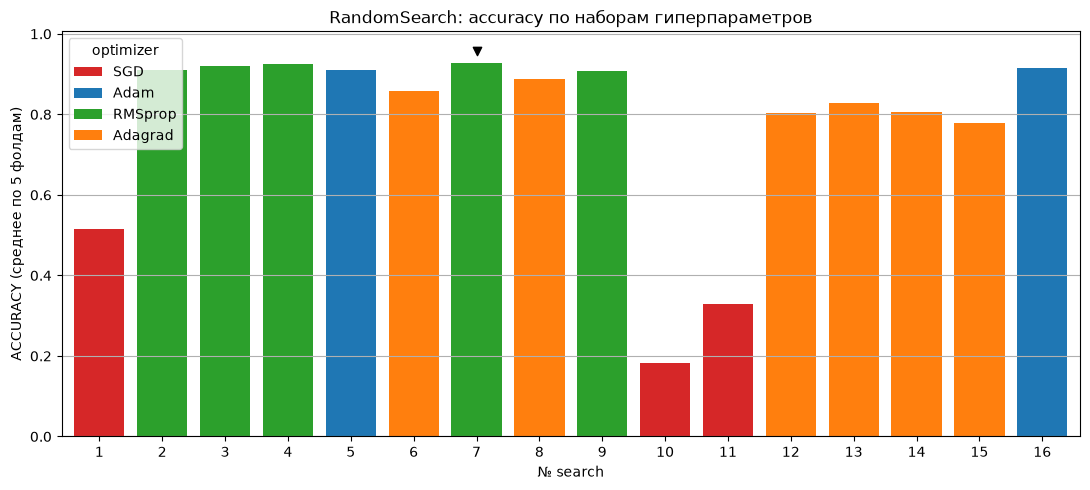

In [15]:
colors = {"SGD": "tab:red", "Adam": "tab:blue", "RMSprop": "tab:green", "Adagrad": "tab:orange"}

plt.figure(figsize=(11, 5))
plt.bar(results["№ search"], results["ACCURACY"],
        color=[colors[o] for o in results["optimizer"]])

# подписываем лучший набор
plt.scatter([best["№ search"]], [best["ACCURACY"] + 0.03], marker="v", color="black")

for o, c in colors.items():
    plt.bar(0, 0, color=c, label=o)      # только для легенды

plt.xticks(results["№ search"])
plt.xlim(0.4, 16.6)
plt.xlabel("№ search")
plt.ylabel("ACCURACY (среднее по 5 фолдам)")
plt.title("RandomSearch: accuracy по наборам гиперпараметров")
plt.legend(title="optimizer")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

Разброс между наборами огромный — от 0.18 до 0.93, и цвет столбиков сразу показывает, откуда он берется:
все красные (SGD) столбики внизу, зеленые (RMSprop) и синие (Adam) — наверху.

Теперь посмотрим на каждый гиперпараметр отдельно: усредним accuracy по всем наборам, где он принимал
данное значение.

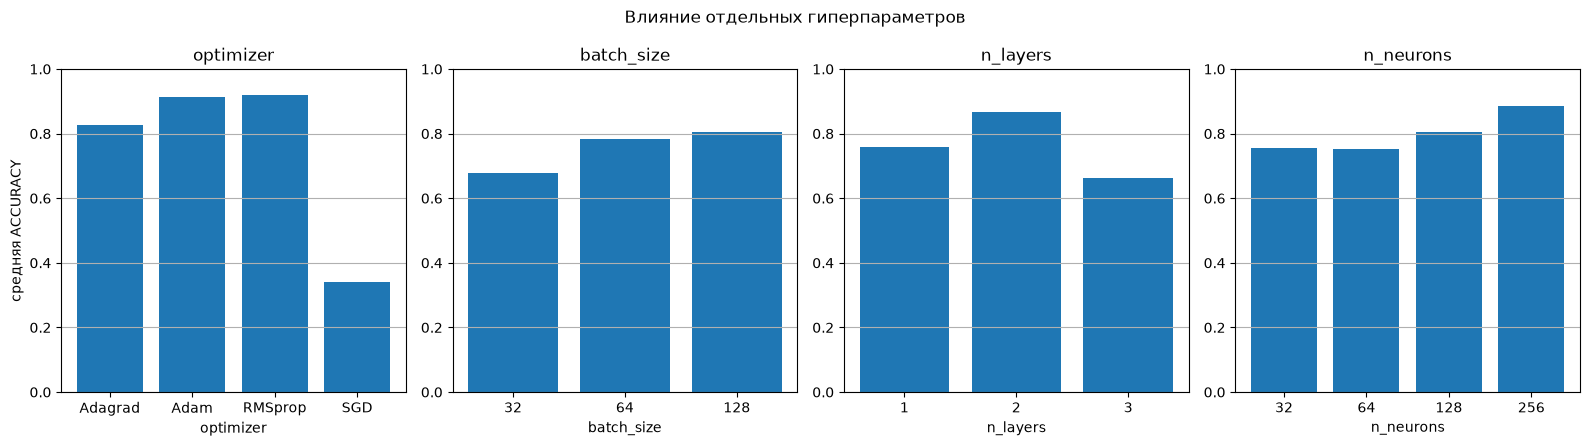

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, name in zip(axes, ["optimizer", "batch_size", "n_layers", "n_neurons"]):
    means = results.groupby(name)["ACCURACY"].mean()
    ax.bar([str(v) for v in means.index], means.values, color="tab:blue")
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y")

axes[0].set_ylabel("средняя ACCURACY")
plt.suptitle("Влияние отдельных гиперпараметров")
plt.tight_layout()
plt.show()

Решает оптимизатор: RMSprop и Adam дают в среднем около 0.92, Adagrad — 0.83, а SGD проваливается до 0.34.
По остальным трем гиперпараметрам столбики почти ровные, и разницу между ними объясняет не сам
гиперпараметр, а то, какие оптимизаторы случайно попали в наборы с этим значением: например,
`batch_size = 32` выглядит хуже всех только потому, что из трех таких наборов один оказался с SGD.
Если сравнивать между собой только наборы с RMSprop (№ 2, 3, 4, 7, 9), то `batch_size = 32` дает
0.926-0.928, а 64 и 128 — 0.907-0.919; число слоев и нейронов при этом почти ничего не меняет.

### Шаг 8. Проверяем лучший набор на тестовой выборке

Кросс-валидация нужна была только для выбора набора. Теперь обучим сеть с лучшими гиперпараметрами
на всей подвыборке из 5000 примеров и посмотрим метрики на честной тестовой выборке (10000 картинок
из `mnist_test.csv`), которую поиск ни разу не видел.

In [17]:
torch.manual_seed(42)

model = make_model(int(best["n_layers"]), int(best["n_neurons"]))
opt = optimizers[best["optimizer"]](model.parameters(), lr=lr)
batch = int(best["batch_size"])

X_te = torch.tensor(X_test)
y_te = torch.tensor(y_test, dtype=torch.long)

for ep in range(epochs):
    idx = torch.randperm(len(X_t))
    for i in range(0, len(X_t), batch):
        b = idx[i:i + batch]
        opt.zero_grad()
        loss = loss_fn(model(X_t[b]), y_t[b])
        loss.backward()
        opt.step()

with torch.no_grad():
    y_pred = model(X_te).argmax(dim=1).numpy()

print("метрики лучшего набора на тестовой выборке:")
print("Accuracy  =", round(accuracy_score(y_test, y_pred), 4))
print("Precision =", round(precision_score(y_test, y_pred, average="macro"), 4))
print("Recall    =", round(recall_score(y_test, y_pred, average="macro"), 4))
print("F1        =", round(f1_score(y_test, y_pred, average="macro"), 4))

метрики лучшего набора на тестовой выборке:
Accuracy  = 0.9366
Precision = 0.937
Recall    = 0.9359
F1        = 0.9359


## Выводы

Модель из задания 10 обернута в два внешних цикла: **RandomSearch** по наборам гиперпараметров и внутри
каждого набора — стратифицированная кросс-валидация на 5 фолдов. Из сетки в 144 набора случайно взяты 16,
каждый оценен по средним по фолдам Accuracy, Precision, Recall и F1. Чтобы поиск считался за разумное
время, датасет сокращен до стратифицированной подвыборки в 5000 примеров, а число фолдов — до 5
(условие это разрешает); полный перебор всей сетки на 60000 примерах занял бы в сотни раз больше времени.

Лучший набор — **1 скрытый слой, 128 нейронов, batch_size = 32, RMSprop**: Accuracy ≈ 0.928 и F1 ≈ 0.927
на кросс-валидации. На тестовой выборке из 10000 картинок этот набор дает 0.937 — даже чуть выше, значит
оценка кросс-валидацией не была оптимистичной.

Сильнее всего на результат влияет **оптимизатор**: RMSprop и Adam дают около 0.92, Adagrad — около 0.83,
а SGD с тем же lr = 0.001 и без momentum за 15 эпох не успевает обучиться и остается на 0.18-0.51.
Это ожидаемо: у RMSprop и Adam шаг для каждого веса подстраивается автоматически, а SGD с таким мелким
фиксированным шагом требует куда больше эпох. Второй по силе — `batch_size`, но его эффект виден только
внутри одного оптимизатора: среди наборов с RMSprop мелкий батч 32 дает 0.927, а 64 и 128 — 0.907-0.919
(при батче 32 за эпоху делается в четыре раза больше обновлений весов). Размер сети (`n_layers`,
`n_neurons`) на MNIST почти не важен — одного скрытого слоя на 128 нейронов достаточно, а лишние слои
при таком количестве эпох скорее замедляют обучение, чем помогают. Средние по отдельным гиперпараметрам
на графике выше показывают и предел RandomSearch: 16 случайных наборов хватает, чтобы уверенно выделить
главный гиперпараметр, но не чтобы аккуратно сравнить второстепенные.